In [ ]:
here::i_am("rna_atac/differential/RNA.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(tradeSeq))
suppressPackageStartupMessages(library(slingshot))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(BiocParallel))
suppressPackageStartupMessages(library(cowplot))

#suppressPackageStartupMessages(library(circlize))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

# outdir
args = list()
args$groupA = 'WT'
args$groupB = 'KO'
opts$groups = c(args$groupA, args$groupB)

args$outdir = file.path(io$basedir, 'results/rna_atac/differential/Accessibility/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

args$peakmtx = file.path(io$basedir, 'processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds')



here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [ ]:
# load RNA data
sce_al = readRDS(sprintf('%s/sce_al.rds', args$outdir))

In [3]:
# Load ATAC data
atac.sce = readRDS(args$peakmtx)
# Convert to SCE
peak.mtx = as(atac.sce, 'SingleCellExperiment')
assayNames(atac.sce) <- "counts"


In [4]:
# Add pseudotime
atac.sce = atac.sce[,match(colnames(sce_al), colnames(atac.sce))]
colData(atac.sce) = colData(sce_al)

In [5]:
atac.sce

class: RangedSummarizedExperiment 
dim: 234908 16999 
metadata(0):
assays(1): counts
rownames(234908): chr1:3003470-3004070 chr1:3035598-3036198 ...
  chrX:169925416-169926016 chrX:169937236-169937836
rowData names(1): idx
colnames(16999): 2_Eo_DEG_G9_day3_5_VC#AAACAGCCATGGAGGC-1
  2_Eo_DEG_G9_day3_5_VC#AAACATGCAGAATGAC-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(29): barcode sample ... slingPseudotime_1 pseudotime

In [13]:
# Calculate peak statistics
acc.dt <- data.table(
    peak = rownames(atac.sce),
    cdr_groupA = rowMeans(assay(atac.sce, 'counts')[,atac.sce$genotype == args$groupA]>0) %>% round(2),
    cdr_groupB = rowMeans(assay(atac.sce, 'counts')[,atac.sce$genotype == args$groupB]>0) %>% round(2),
    var_groupA = rowVars(assay(atac.sce, 'counts')[,atac.sce$genotype == args$groupA]) %>% round(2),
    var_groupB = rowVars(assay(atac.sce, 'counts')[,atac.sce$genotype == args$groupB]) %>% round(2)
)

In [14]:
head(acc.dt)

peak,cdr_groupA,cdr_groupB,var_groupA,var_groupB
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3003470-3004070,0.03,0.06,0.18,0.32
chr1:3035598-3036198,0.02,0.03,0.10,0.11
chr1:3062639-3063239,0.01,0.02,0.05,0.06
chr1:3191587-3192187,0.15,0.21,0.64,0.88
chr1:3263590-3264190,0.02,0.04,0.10,0.14
chr1:3482948-3483548,0.03,0.03,0.10,0.14


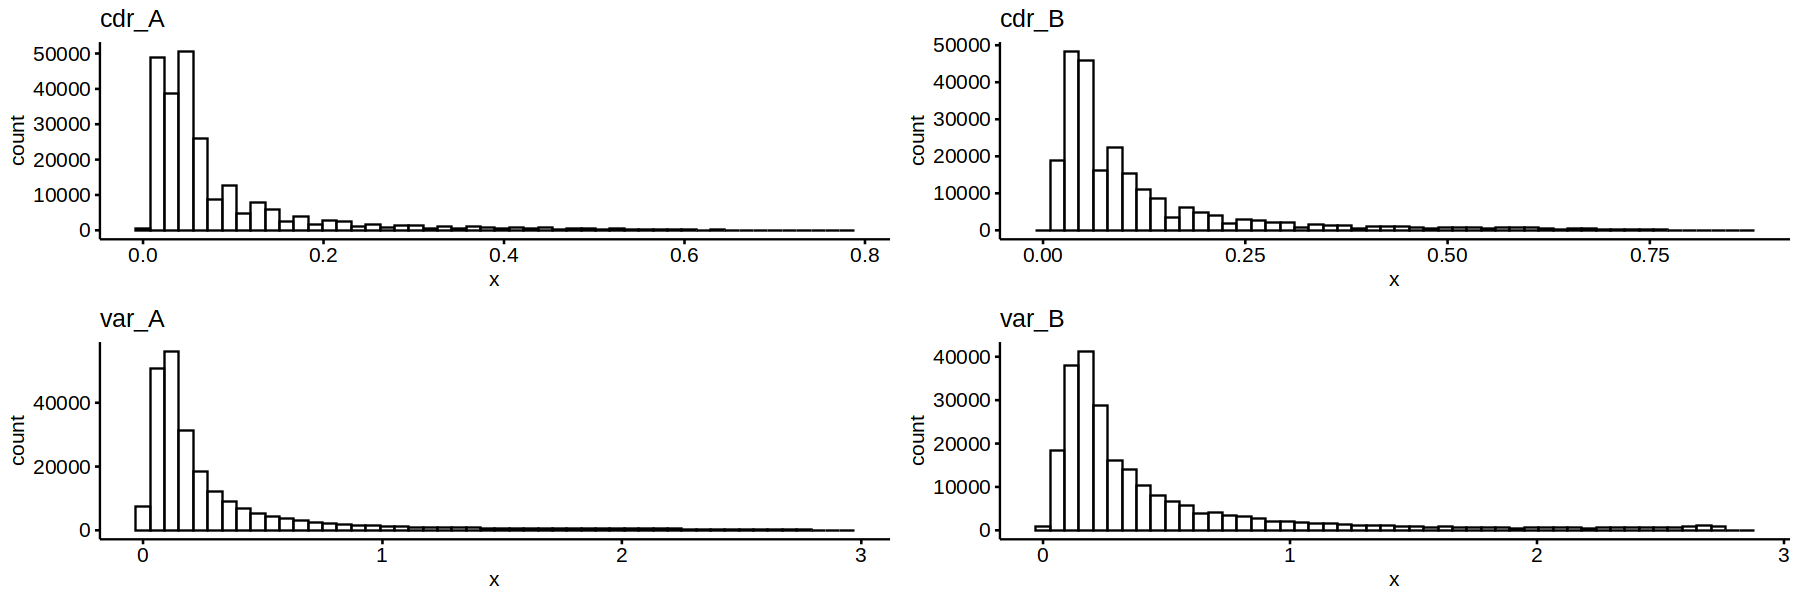

In [18]:
p1 = gghistogram(acc.dt$cdr_groupA, bins=50) + ggtitle('cdr_A')
p2 = gghistogram(acc.dt$cdr_groupB, bins=50)+ ggtitle('cdr_B')
p3 = gghistogram(acc.dt$var_groupA, bins=50)+ ggtitle('var_A')
p4 = gghistogram(acc.dt$var_groupB, bins=50)+ ggtitle('var_B')
options(repr.plot.width=15, repr.plot.height=5)
p = ggarrange(p1, p2, p3, p4, ncol=2)
plot_grid(plotlist = p, ncol = 1)

In [19]:
# Min values set very low to keep genes that are very specific
min.cdr = 0.1
min.var = 0.1

# filter genes
peaks.to.use <- acc.dt[var_groupA>=min.var | var_groupB>=min.var,][cdr_groupA>=min.cdr | cdr_groupB>=min.cdr,peak]
length(peaks.to.use)

[1] 82775

In [47]:
sce_al = atac.sce[peaks.to.use,]

In [48]:
sce_al

class: SingleCellExperiment 
dim: 73423 16999 
metadata(0):
assays(1): counts
rownames(73423): chr1:3191587-3192187 chr1:3670533-3671133 ...
  chrX:169320162-169320762 chrX:169879265-169879865
rowData names(1): idx
colnames(16999): 2_Eo_DEG_G9_day3_5_VC#AAACAGCCATGGAGGC-1
  2_Eo_DEG_G9_day3_5_VC#AAACATGCAGAATGAC-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(29): barcode sample ... slingPseudotime_1 pseudotime
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [49]:
saveRDS(sce_al, sprintf('%s/sce_al.rds', args$outdir))

In [30]:
# Min values set very low to keep genes that are very specific
min.cdr = 0.3
min.var = 2

# filter genes
peaks.to.use <- acc.dt[var_groupA>=min.var | var_groupB>=min.var,][cdr_groupA>=min.cdr | cdr_groupB>=min.cdr,peak]
length(peaks.to.use)

[1] 9082

In [31]:
# Min values set very low to keep genes that are very specific
min.cdr = 0.3
min.var = 2

# filter genes
peaks.to.use <- acc.dt[var_groupA>=min.var | var_groupB>=min.var,][cdr_groupA>=min.cdr | cdr_groupB>=min.cdr,peak]
length(peaks.to.use)
sce_al_test = atac.sce[peaks.to.use,]

saveRDS(sce_al_test, sprintf('%s/sce_al_test.rds', args$outdir))

[1] 9082

# Analysis

In [30]:
sceGAM = readRDS(paste0(args$outdir,"/sceGAM_v1_test.rds"))
sce_al = readRDS(sprintf('%s/sce_al_test.rds', args$outdir))

In [50]:
# Differential testing

args$logFC_thr = 0.5
args$FDR_thr = 0.05

condRes <- conditionTest(sceGAM, l2fc = args$logFC_thr)
condRes$padj <- p.adjust(condRes$pvalue, "fdr")

In [51]:
condRes = condRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>%
    .[,sig:=ifelse(padj<=args$FDR_thr, TRUE, FALSE)] %>%
    .[order(padj, -waldStat)]

In [52]:
head(condRes, 10)

gene,waldStat,df,pvalue,padj,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
chr16:11469982-11470582,144.50710,3,0.000000e+00,0.000000e+00,TRUE
chr2:30642497-30643097,117.69073,3,0.000000e+00,0.000000e+00,TRUE
chr7:140935405-140936005,116.45808,3,0.000000e+00,0.000000e+00,TRUE
chr12:86379189-86379789,84.83694,3,0.000000e+00,0.000000e+00,TRUE
chr7:79789149-79789749,83.21210,2,0.000000e+00,0.000000e+00,TRUE
chr12:86836568-86837168,73.73398,3,6.661338e-16,1.008305e-12,TRUE
chr4:128652576-128653176,73.05069,3,9.992007e-16,1.296392e-12,TRUE
chr6:145998536-145999136,66.35395,3,2.575717e-14,2.610388e-11,TRUE
chr16:31535112-31535712,66.34093,3,2.586820e-14,2.610388e-11,TRUE


In [53]:
plot_traj = function(gene, size=0.1, alpha=0.1){
    ggplot(as.data.frame(colData(sce_filt)[,-grep('slingshot', colnames(colData(sce_filt)))]), aes(pseudotime, as.vector(assay(sce_filt, 'counts')[gene,]), col=genotype)) + 
        geom_point(size=size, alpha=alpha) + 
        geom_smooth() + 
        scale_colour_manual(values=c('KO'='red', 'WT'='black'), name='genotype') + 
        ylab('logcounts') + 
        xlab('Pseudotime') + 
        ggtitle(gene) + 
        theme_bw() + 
        theme(text=element_text(size=20))
}

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


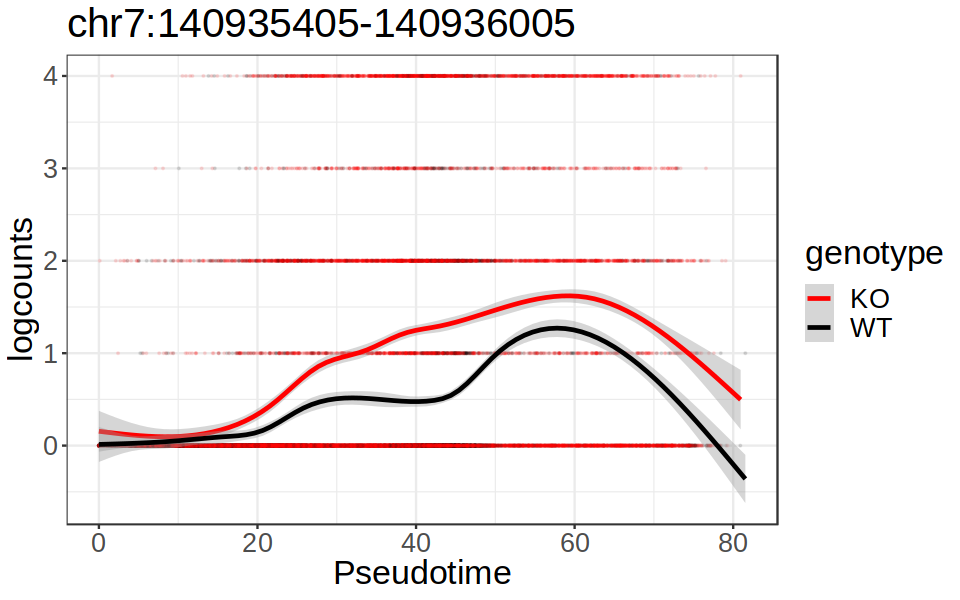

In [54]:
plot_traj(condRes[order(-waldStat)][3,gene])

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


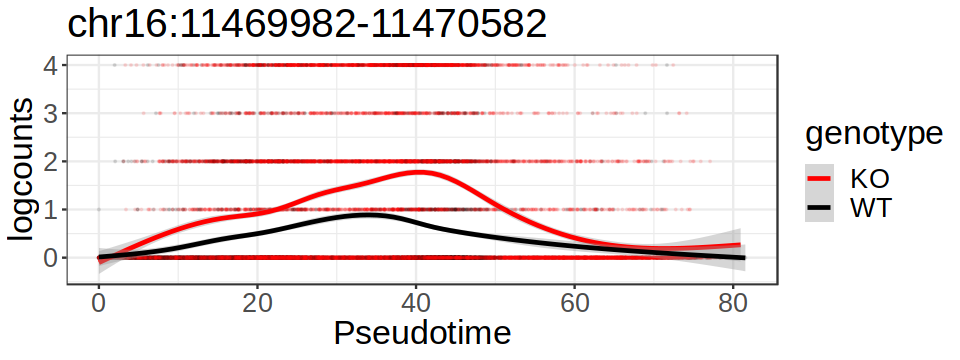

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


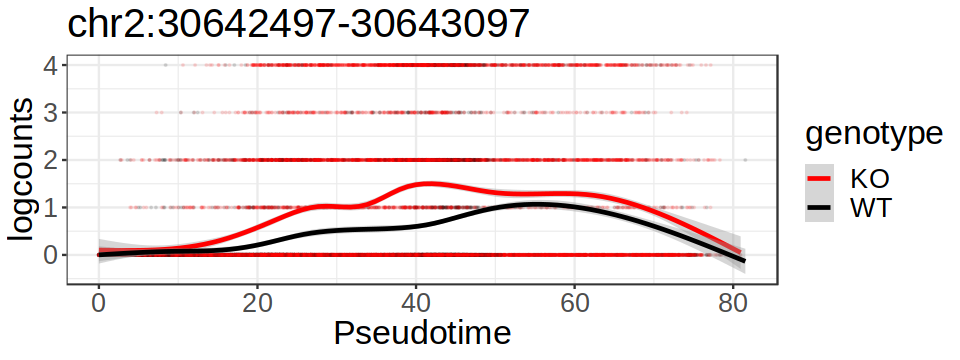

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


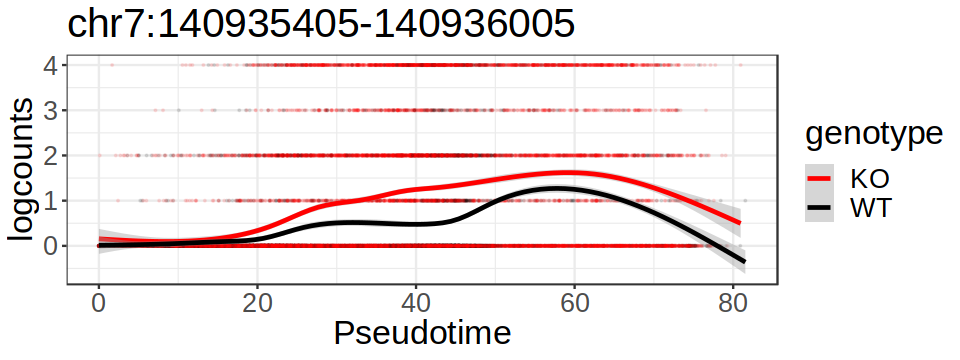

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


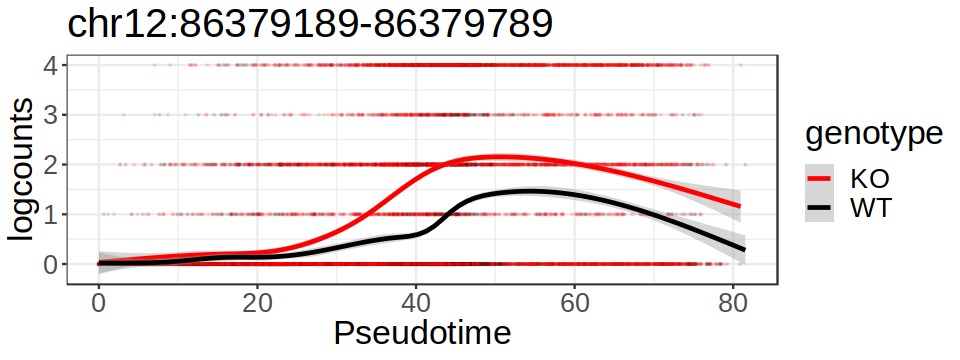

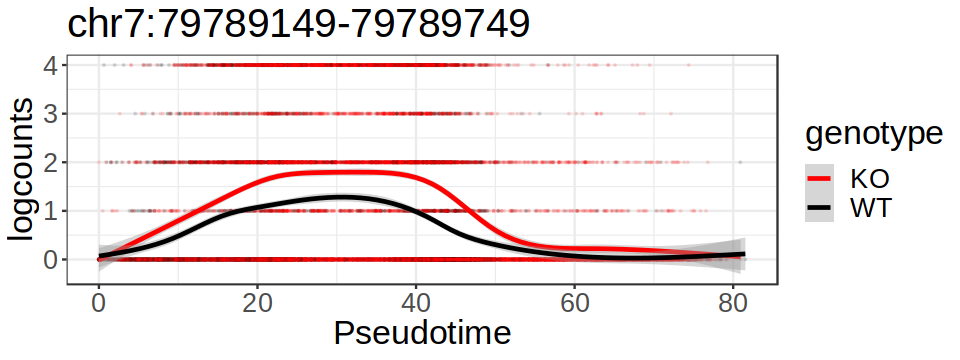

In [55]:
options(repr.plot.height=3, repr.plot.width=8)
mclapply(head(condRes[order(-waldStat)]$gene, 5), plot_traj, mc.cores=24)

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


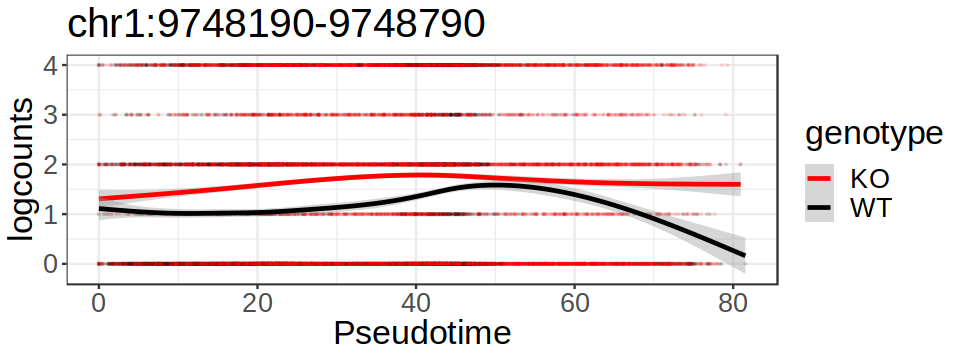

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


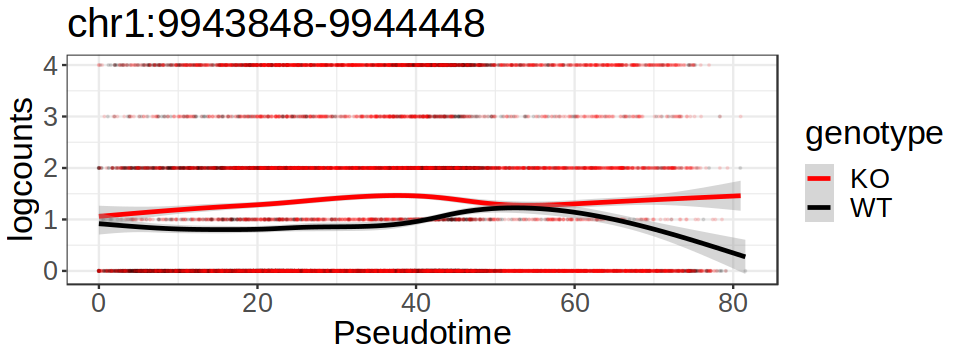

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


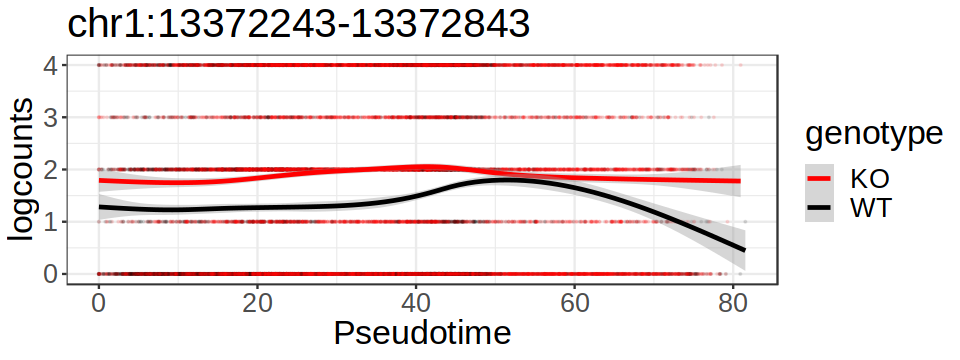

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


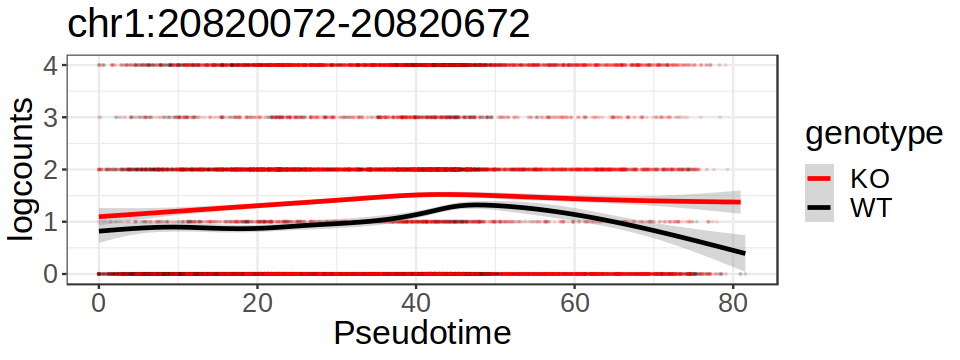

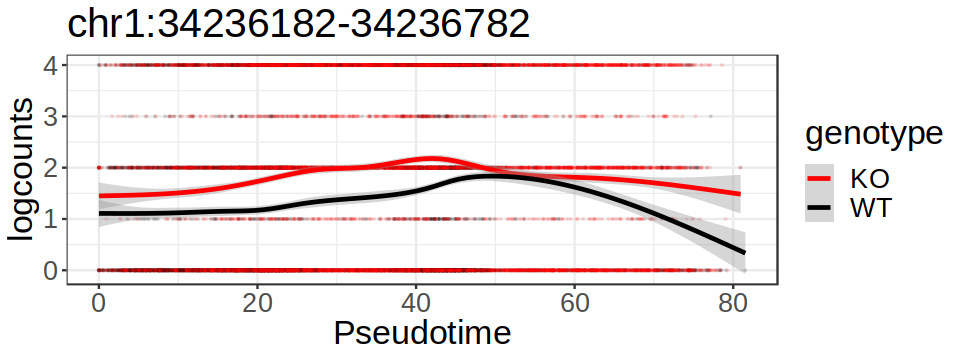

In [56]:
options(repr.plot.height=3, repr.plot.width=8)
mclapply(head(condRes[order(waldStat)]$gene, 5), plot_traj, mc.cores=24)

In [57]:
trans <- div_gradient_pal(low='#5a77ff', mid='lightyellow', high='#d66468')
cols <- trans(seq(0,1, length.out=20))

In [58]:
library(circlize)
suppressPackageStartupMessages(library(ComplexHeatmap))


In [59]:
col_fun = colorRamp2(seq(0, 50, 5), viridis::viridis(length(seq(0, 50, 5))))

In [60]:
ha = HeatmapAnnotation(pseudotime = 1:50,
                       col = list(pseudotime = col_fun))

In [61]:
length(condRes[sig==TRUE, gene])

[1] 288

In [76]:
head(condRes, 10)

gene,waldStat,df,pvalue,padj,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
chr16:11469982-11470582,144.50710,3,0.000000e+00,0.000000e+00,TRUE
chr2:30642497-30643097,117.69073,3,0.000000e+00,0.000000e+00,TRUE
chr7:140935405-140936005,116.45808,3,0.000000e+00,0.000000e+00,TRUE
chr12:86379189-86379789,84.83694,3,0.000000e+00,0.000000e+00,TRUE
chr7:79789149-79789749,83.21210,2,0.000000e+00,0.000000e+00,TRUE
chr12:86836568-86837168,73.73398,3,6.661338e-16,1.008305e-12,TRUE
chr4:128652576-128653176,73.05069,3,9.992007e-16,1.296392e-12,TRUE
chr6:145998536-145999136,66.35395,3,2.575717e-14,2.610388e-11,TRUE
chr16:31535112-31535712,66.34093,3,2.586820e-14,2.610388e-11,TRUE


In [73]:
conditionGenes = head(condRes[sig==TRUE, gene], 10)

minmax = function(x){(x-min(x))/(max(x)-min(x))}

yhatSmooth <- predictSmooth(sceGAM, gene = conditionGenes, nPoints = 50, tidy = FALSE)
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 
WT = yhatSmooth_minmax[, grepl('WT', colnames(yhatSmooth_minmax))]
KO = yhatSmooth_minmax[, grepl('KO', colnames(yhatSmooth_minmax))]

# Clustering
k = 6
group = kmeans(yhatSmooth_minmax, centers = k)$cluster
row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

hm_list = Heatmap(WT, 
                  cluster_rows = row_clust,
                  cluster_columns = FALSE,
                  column_title = 'Wild Type',
                  show_column_names  = FALSE,
                  row_split = k,
                  #row_split = as.data.frame(group), 
                  #km = 6,
                  col = cols,
                  heatmap_legend_param = list(title = 'Smoothed Expression'), 
                  top_annotation = ha) + 
          Heatmap(KO, 
                  cluster_columns = FALSE, 
                  column_title = 'Eomes Knock Down',
                  show_column_names  = FALSE,
                  col = cols,
                  show_heatmap_legend = F, 
                  top_annotation = ha)

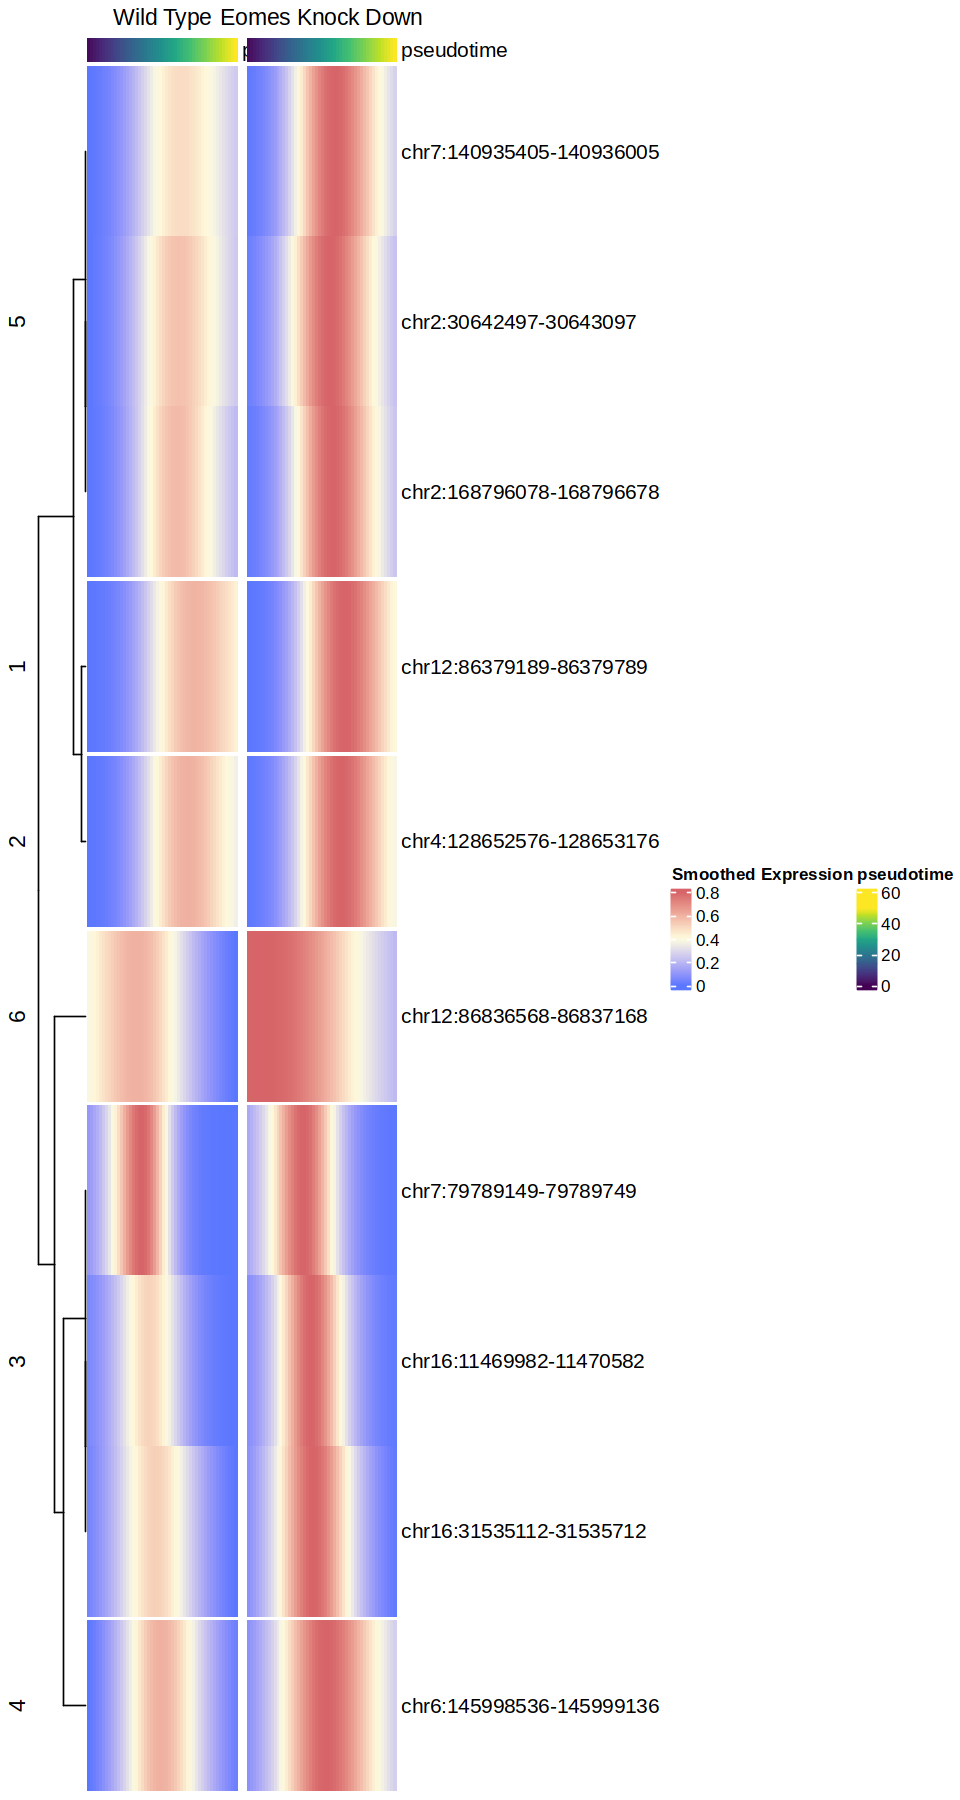

In [74]:
options(repr.plot.height=15, repr.plot.width=8)
draw(hm_list)

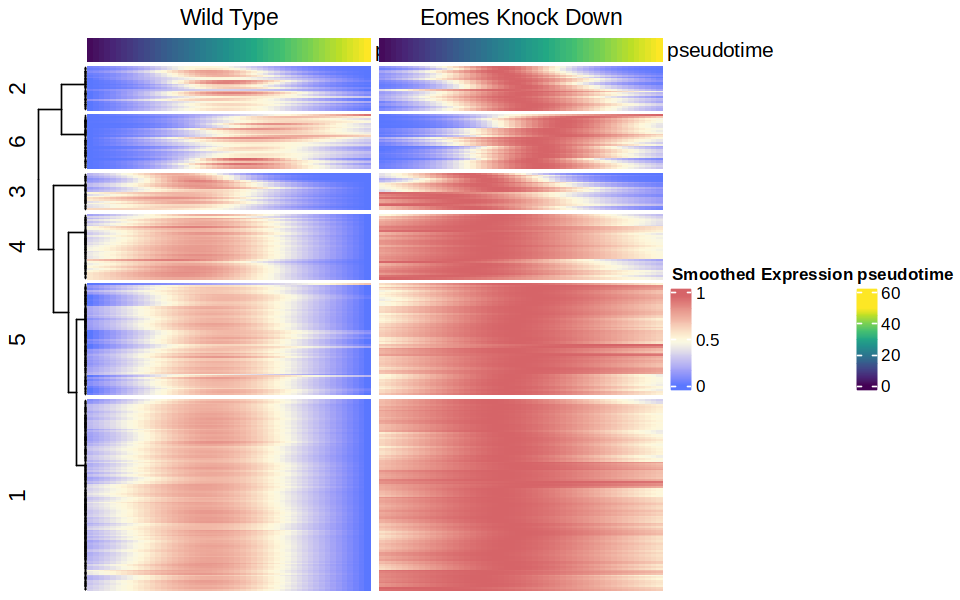

In [70]:
hm_list = Heatmap(WT, 
                  cluster_rows = row_clust,
                  cluster_columns = FALSE,
                  column_title = 'Wild Type',
                  show_column_names  = FALSE,
                  row_split = k,
                  #row_split = as.data.frame(group), 
                  #km = 6,
                  col = cols,
                  heatmap_legend_param = list(title = 'Smoothed Expression'), 
                  top_annotation = ha) + 
          Heatmap(KO, 
                  cluster_columns = FALSE, 
                  column_title = 'Eomes Knock Down',
                  show_column_names  = FALSE,
                  show_row_names  = FALSE,
                  col = cols,
                  show_heatmap_legend = F, 
                  top_annotation = ha)

options(repr.plot.height=5, repr.plot.width=8)
draw(hm_list)

`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.

`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



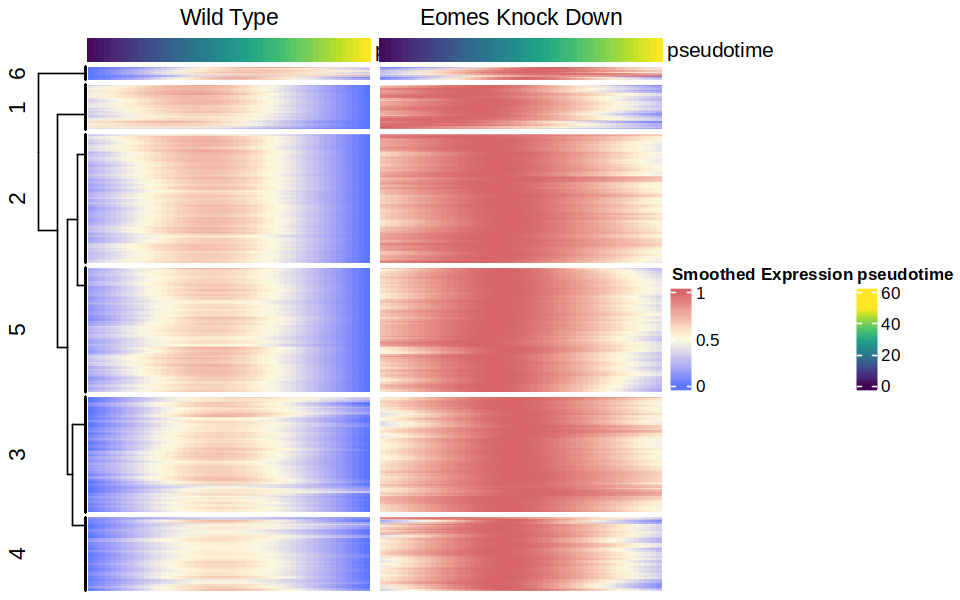

In [71]:
# now for least significant peaks
conditionGenes = condRes[sig==FALSE, gene]

minmax = function(x){(x-min(x))/(max(x)-min(x))}

yhatSmooth <- predictSmooth(sceGAM, gene = conditionGenes, nPoints = 50, tidy = FALSE)
yhatSmooth_minmax = t(apply(yhatSmooth, 1, minmax)) 
WT = yhatSmooth_minmax[, grepl('WT', colnames(yhatSmooth_minmax))]
KO = yhatSmooth_minmax[, grepl('KO', colnames(yhatSmooth_minmax))]

# Clustering
k = 6
group = kmeans(yhatSmooth_minmax, centers = k)$cluster
row_clust = cluster_within_group(t(yhatSmooth_minmax), group)

hm_list = Heatmap(WT, 
                  cluster_rows = row_clust,
                  cluster_columns = FALSE,
                  column_title = 'Wild Type',
                  show_column_names  = FALSE,
                  row_split = k,
                  #row_split = as.data.frame(group), 
                  #km = 6,
                  col = cols,
                  heatmap_legend_param = list(title = 'Smoothed Expression'), 
                  top_annotation = ha) + 
          Heatmap(KO, 
                  cluster_columns = FALSE, 
                  column_title = 'Eomes Knock Down',
                  show_column_names  = FALSE,
                  show_row_names  = FALSE,
                  col = cols,
                  show_heatmap_legend = F, 
                  top_annotation = ha)

options(repr.plot.height=5, repr.plot.width=8)
draw(hm_list)

In [1]:
here::i_am("rna_atac/differential/RNA.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(destiny))
suppressPackageStartupMessages(library(tradeSeq))
suppressPackageStartupMessages(library(slingshot))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(BiocParallel))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 70

# outdir
args = list()
args$groupA = 'WT'
args$groupB = 'KO'
opts$groups = c(args$groupA, args$groupB)

args$outdir = file.path(io$basedir, 'results/rna_atac/differential/Accessibility/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)


sce_filt = readRDS(sprintf('%s/sce_al_test.rds', args$outdir))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [2]:
sce_filt

class: RangedSummarizedExperiment 
dim: 9082 16999 
metadata(0):
assays(1): counts
rownames(9082): chr1:3671493-3672093 chr1:4571660-4572260 ...
  chrX:166510201-166510801 chrX:169320162-169320762
rowData names(1): idx
colnames(16999): 2_Eo_DEG_G9_day3_5_VC#AAACAGCCATGGAGGC-1
  2_Eo_DEG_G9_day3_5_VC#AAACATGCAGAATGAC-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(29): barcode sample ... slingPseudotime_1 pseudotime

In [3]:
head(sce_filt$pseudotime)

[1] 27.16748 18.48415 15.78331 14.76469 12.32240 19.09569

In [4]:
# Set all cells to belong to one trajectory
cellWeights <- rep(1,ncol(sce_filt))

# create a model matrix -> Comparing across replicates
U <- model.matrix(~sce_filt$replicate)

sceGAM <- fitGAM(counts = assay(sce_filt, 'counts')[1:500,], 
                 conditions = factor(sce_filt$genotype, levels=c('KO', 'WT')),
                 U = U,
                 pseudotime= sce_filt$pseudotime,
                 cellWeights=cellWeights,
                 nknots=3, 
                 parallel = TRUE,
                 BPPARAM=BPPARAM,
                 verbose=F)

Fitting lineages with multiple conditions. This method has been tested on a couple of datasets, but is still in an experimental phase.



In [8]:
# Differential testing

args$logFC_thr = 0.75
args$FDR_thr = 0.05

condRes <- conditionTest(sceGAM, l2fc = args$logFC_thr)
condRes$padj <- p.adjust(condRes$pvalue, "fdr")

In [9]:
condRes = condRes %>% as.data.table(keep.rownames=T) %>%
    setnames('rn', 'gene') %>%
    .[,sig:=ifelse(padj<=args$FDR_thr, TRUE, FALSE)] %>%
    .[order(padj, -waldStat)]

In [27]:
plot_traj = function(gene, size=0.1, alpha=0.1){
    ggplot(as.data.frame(colData(sce_filt)[,-grep('slingshot', colnames(colData(sce_filt)))]), aes(pseudotime, as.vector(assay(sce_filt, 'counts')[gene,]), col=genotype)) + 
        geom_point(size=size, alpha=alpha) + 
        geom_smooth() + 
        scale_colour_manual(values=c('KO'='red', 'WT'='black'), name='genotype') + 
        ylab('logcounts') + 
        xlab('Pseudotime') + 
        ggtitle(gene) + 
        theme_bw() + 
        theme(text=element_text(size=20))
}

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


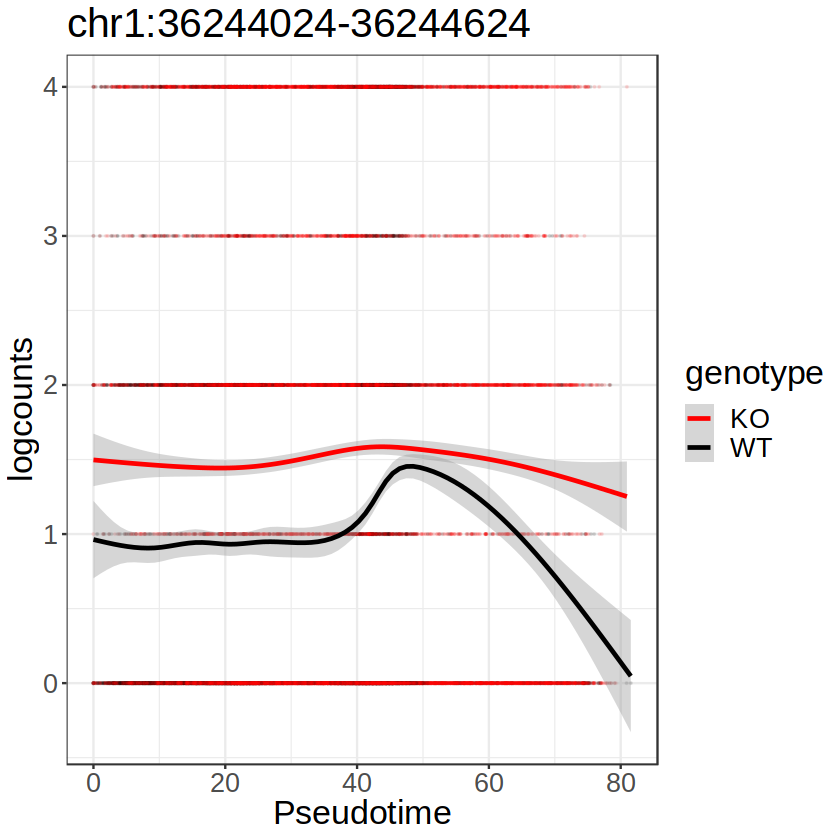

In [29]:
plot_traj(condRes[order(-waldStat)][100,gene])

In [77]:
atac.se = sce_filt[1:2000,]

In [78]:
atac.se

class: RangedSummarizedExperiment 
dim: 2000 16999 
metadata(0):
assays(1): counts
rownames(2000): chr1:3671493-3672093 chr1:4571660-4572260 ...
  chr4:116626527-116627127 chr4:116685202-116685802
rowData names(1): idx
colnames(16999): 2_Eo_DEG_G9_day3_5_VC#AAACAGCCATGGAGGC-1
  2_Eo_DEG_G9_day3_5_VC#AAACATGCAGAATGAC-1 ...
  rv_eo_deg_day4_dtag#TTTGTGTTCATTTGTC-1
  rv_eo_deg_day4_dtag#TTTGTTGGTACTTAGG-1
colData names(29): barcode sample ... slingPseudotime_1 pseudotime

In [79]:
args$ndims = 5

In [80]:
#############################
## ATAC TFIDF normalisation ##
#############################

atac_tfidf.mtx <- tfidf(assay(atac.se), method=1, scale.factor=1e4)

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,12737015,680.3,22653683,1209.9,12737015,680.3
Vcells,480662188,3667.2,736903704,5622.2,480662188,3667.2


In [97]:
plot_traj1 = function(gene, size=0.1, alpha=0.1){
    ggplot(as.data.frame(colData(sce_filt)[,-grep('slingshot', colnames(colData(sce_filt)))]), aes(pseudotime, as.vector(atac_tfidf.mtx[gene,]), col=genotype)) + 
        geom_point(size=size, alpha=alpha) + 
        geom_smooth() + 
        scale_colour_manual(values=c('KO'='red', 'WT'='black'), name='genotype') + 
        ylab('logcounts') + 
        xlab('Pseudotime') + 
        ggtitle(gene) + 
        theme_bw() + 
        theme(text=element_text(size=20))
}

In [98]:
plot_traj2 = function(gene, size=0.1, alpha=0.1){
    ggplot(as.data.frame(colData(sce_filt)[,-grep('slingshot', colnames(colData(sce_filt)))]), aes(pseudotime, as.vector(assay(sce_filt, 'counts')[gene,]), col=genotype)) + 
        geom_point(size=size, alpha=alpha) + 
        geom_smooth() + 
        scale_colour_manual(values=c('KO'='red', 'WT'='black'), name='genotype') + 
        ylab('logcounts') + 
        xlab('Pseudotime') + 
        ggtitle(gene) + 
        theme_bw() + 
        theme(text=element_text(size=20))
}

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


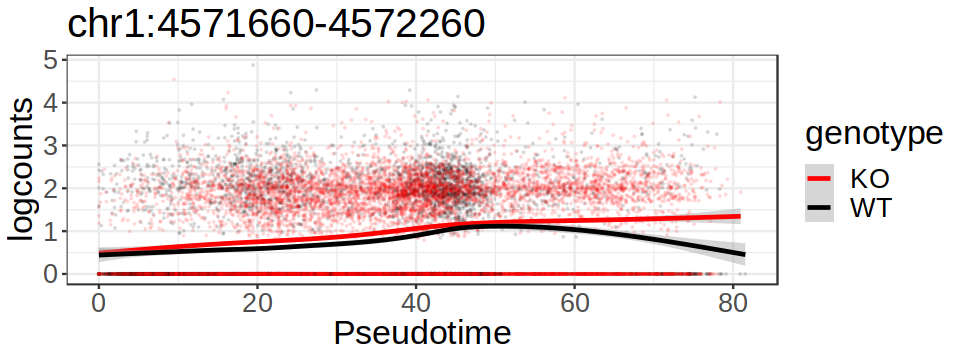

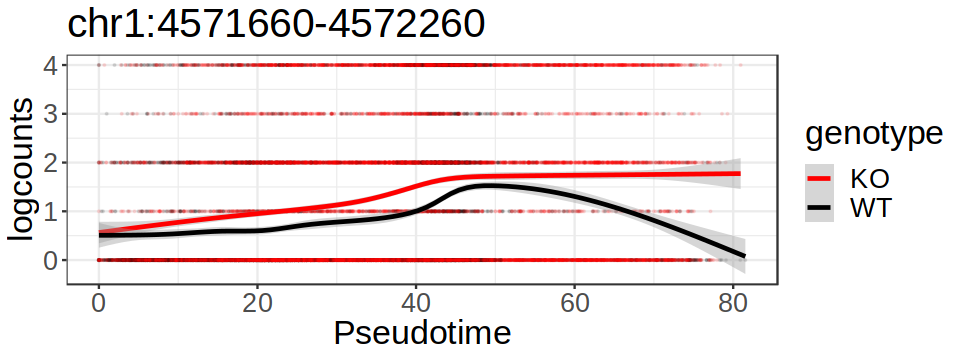

In [100]:
peak = rownames(atac_tfidf.mtx)[2]
plot_traj1(peak)
plot_traj2(peak)

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


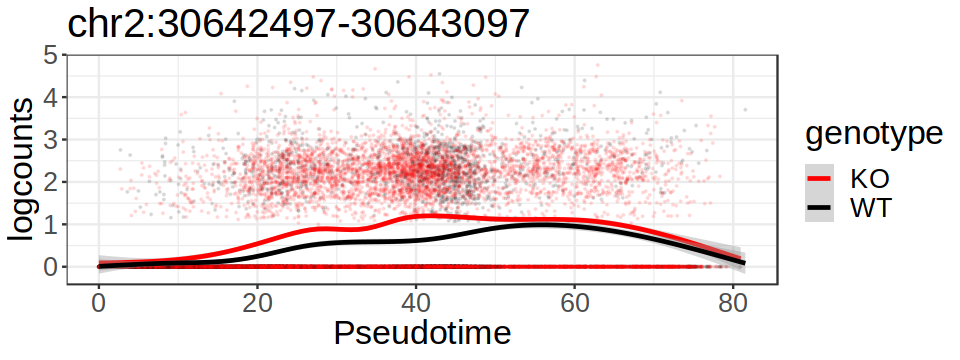

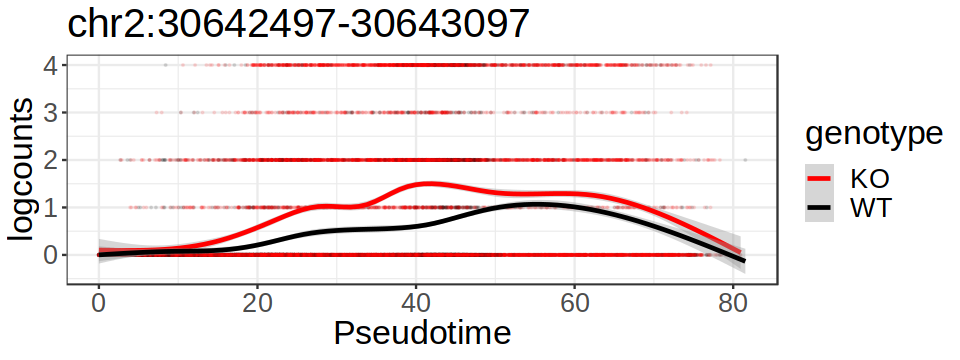

In [114]:
conditionGenes = condRes[sig==TRUE, gene]
peak = conditionGenes[conditionGenes %in% rownames(atac_tfidf.mtx)][1]
plot_traj1(peak)
plot_traj2(peak)

In [115]:
peak

[1] "chr2:30642497-30643097"

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'
`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


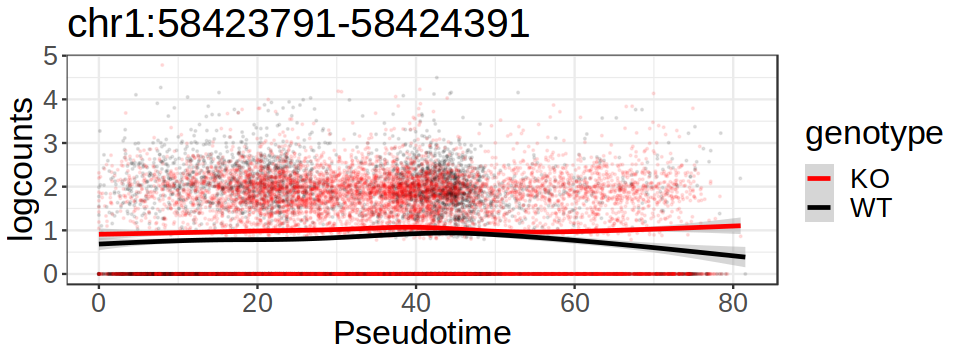

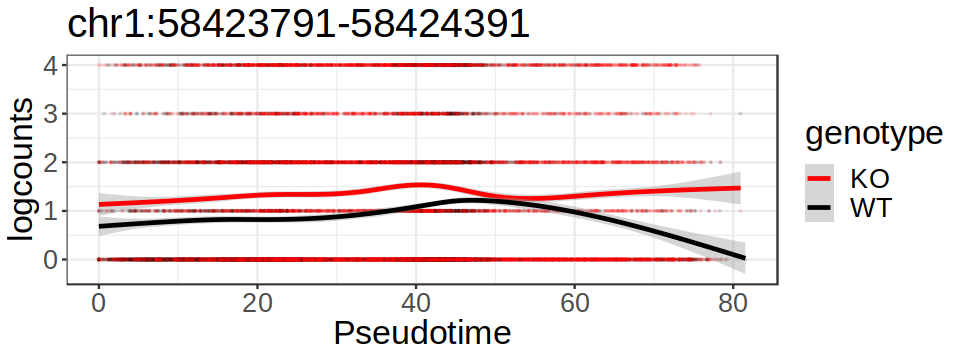

In [113]:
conditionGenes = condRes[sig==FALSE, gene]
peak = conditionGenes[conditionGenes %in% rownames(atac_tfidf.mtx)][1]
plot_traj1(peak)
plot_traj2(peak)